<a href="https://colab.research.google.com/github/MiguelAngeloTr/Deep_Learning/blob/main/C3/GAN_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uso de GAN para Generar Imágenes de Dígitos Escritos a Mano

**GAN (Red Generativa Adversarial)** [[1]](#ref1) es un marco propuesto por Ian Goodfellow, Yoshua Bengio y otros en 2014.

Un GAN puede ser entrenado para generar imágenes a partir de ruidos aleatorios. Por ejemplo, podemos entrenar un GAN en MNIST (conjunto de datos de dígitos escritos a mano) para generar imágenes de dígitos que parezcan imágenes de dígitos escritos a mano de MNIST, lo que podría utilizarse para entrenar otras redes neuronales.

El código en este cuaderno se basa en el **ejemplo de GAN MNIST en TensorFlow de Udacity** [[2]](#ref2), que utiliza TensorFlow, pero nosotros usamos Keras sobre TensorFlow para una construcción más sencilla de las redes. Muchas de las ideas sobre el entrenamiento provienen de **Cómo entrenar un GAN? Consejos y trucos para hacer que los GAN funcionen** [[4]](#ref4).

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [ ]:
!pip install tensorflow==2.8.0
import tensorflow as tf
print(tf.__version__)

ERROR: Could not find a version that satisfies the requirement tensorflow==2.8.0 (from versions: 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.12.1, 2.13.0rc0, 2.13.0rc1, 2.13.0rc2, 2.13.0, 2.13.1, 2.14.0rc0, 2.14.0rc1, 2.14.0, 2.14.1, 2.15.0rc0, 2.15.0rc1, 2.15.0, 2.15.0.post1, 2.15.1, 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0)
ERROR: No matching distribution found for tensorflow==2.8.0
2.18.0


## MNIST

MNIST es una base de datos ampliamente conocida de dígitos escritos a mano [[3]](#ref3).

In [ ]:
import numpy as np
import keras
import keras.backend as K
from keras.layers import Input, Dense, Activation, LeakyReLU, BatchNormalization
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

Lo siguiente descargará el conjunto de datos MNIST (si aún no está descargado).

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Vamos a examinar imágenes de muestra. Utilizaremos el mapa de colores 'gray' (gris) ya que no tiene información de color.

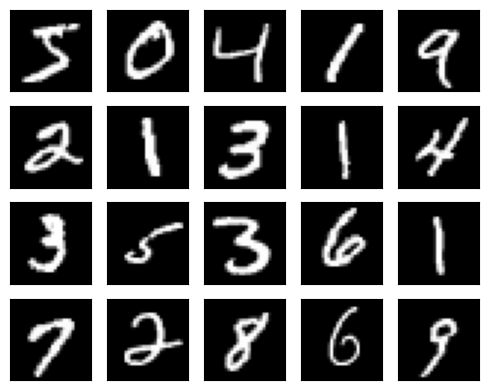

In [ ]:
plt.figure(figsize=(5, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

Todas las imágenes de dígitos MNIST tienen un tamaño de 28x28 píxeles.

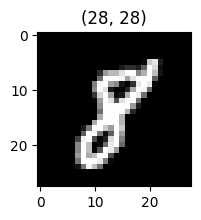

In [ ]:

sample = X_train[17]

plt.figure(figsize=(3, 2))
plt.title(sample.shape)
plt.imshow(sample, cmap='gray')
plt.show()

El tamaño mínimo y máximo de los datos de imagen de MNIST es 0 y 255 respectivamente.

In [ ]:
X_train.min(), X_train.max()

(np.uint8(0), np.uint8(255))

## Generador

Queremos construir un generador que genere imágenes realistas escritas a mano.

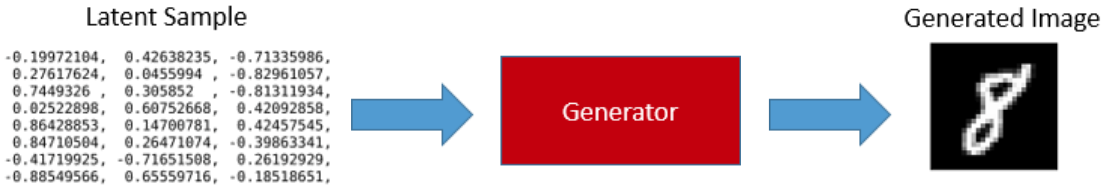

La entrada al generador se llama 'muestra latente', que es una serie de números generados aleatoriamente. Utilizamos la distribución normal en lugar de la distribución uniforme, como se sugiere en [[4]](#ref4).

In [ ]:
def make_latent_samples(n_samples, sample_size):
    #return np.random.uniform(-1, 1, size=(n_samples, sample_size))
    return np.random.normal(loc=0, scale=1, size=(n_samples, sample_size))

El tamaño de la muestra es un hiperparámetro. A continuación, usamos un vector de 100 números generados aleatoriamente como muestra.

In [ ]:
make_latent_samples(1, 100) # Genera una muestra.

array([[ 0.65244002, -2.47828932,  0.13847761, -1.08135375,  0.52143216,
        -0.09961478,  0.90415307, -0.68469897,  1.10023185, -0.14630332,
         0.50762715, -0.84232052,  2.44160708,  0.53049625, -1.18126055,
        -0.99193204, -1.20900491,  0.36476156, -0.27266888,  0.63898391,
        -2.02578271, -0.04148481, -1.68491407,  0.71896061,  0.51617683,
         0.04692958, -0.47723433, -0.82292972,  0.59856647, -1.61523016,
        -1.20750378, -0.62898115, -1.50837477,  0.85305818,  1.90926914,
        -1.08115496, -1.03784624, -0.4208746 , -0.16527952, -0.28150151,
        -0.50630022, -0.02983558, -0.7220689 , -2.15007375,  1.62861818,
         0.43677501,  0.79448923, -0.31265103, -1.53651847,  1.08295082,
        -0.28927272, -1.05686382,  0.05613658, -1.68636659, -0.36036624,
         0.87169473, -0.60665553,  1.26632002,  0.10476968,  0.78166968,
         0.654482  ,  0.13188748,  0.05000696, -1.84526651,  0.1767916 ,
         1.17729732,  1.36371865,  0.42960131, -0.7

El generador es una red neuronal completamente conectada simple con una capa oculta que utiliza la activación de LeakyReLU. Toma una muestra latente (100 valores) y produce 784 puntos de datos, que representan una imagen de dígito (28x28).

In [ ]:
generator = Sequential([Dense(128, input_shape=(100,)), LeakyReLU(alpha=0.01), Dense(784), Activation('tanh')], name='generator')
generator.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 784)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,064 (445.56 KB)

 Trainable params: 114,064 (445.56 KB)

 Non-trainable params: 0 (0.00 B)

La última activación es **tanh**. Según [[4]](#ref4), esto funciona mejor. También significa que debemos reescalar las imágenes de MNIST para que estén en el rango de -1 a 1.

Inicialmente, el generador solo puede producir basura.

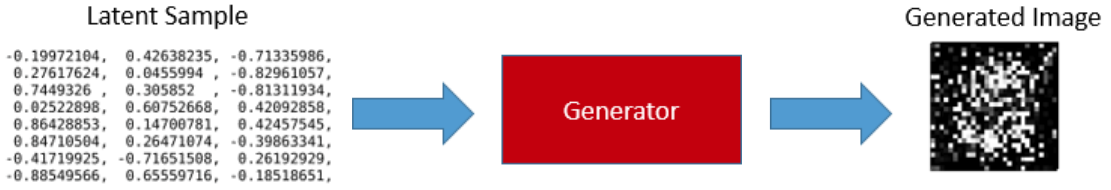

Por lo tanto, el generador necesita aprender cómo generar imágenes realistas escritas a mano a partir de la muestra latente (números generados al azar).

¿Cómo se entrena este generador? Esa es la pregunta que aborda GAN.

Antes de hablar sobre GAN, discutiremos el discriminador.

## Discriminador

El discriminador toma una imagen de un dígito y la clasifica como real (1) o no real (0).

Si la imagen de entrada proviene de la base de datos MNIST, el discriminador debería clasificarla como real.

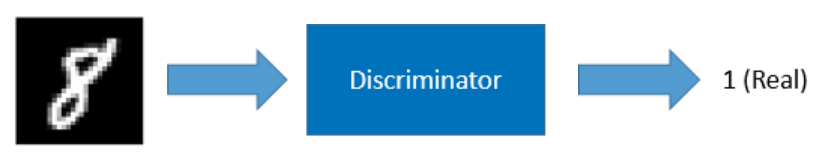

Si la imagen de entrada procede del generador, el discriminador debe clasificarla como falsa.

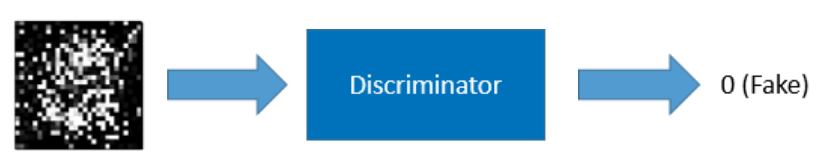

El discriminador es una red neuronal completamente conectada simple con una capa oculta que utiliza la activación de LeakyReLU.

In [ ]:
discriminator = Sequential([Dense(128, input_shape=(784,)), LeakyReLU(alpha=0.01), Dense(1), Activation('sigmoid')], name='discriminator')
discriminator.summary()


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

La última activación es **sigmoidal** para indicar la probabilidad de si la imagen de entrada es real o no.

Entrenamos el discriminador utilizando tanto las imágenes de MNIST como las imágenes generadas por el generador.

## GAN

Conectamos el generador y el discriminador para producir una GAN.

Toma la muestra latente y el generador dentro del GAN produce una imagen de dígito que el discriminador dentro del GAN clasifica como real o falsa.

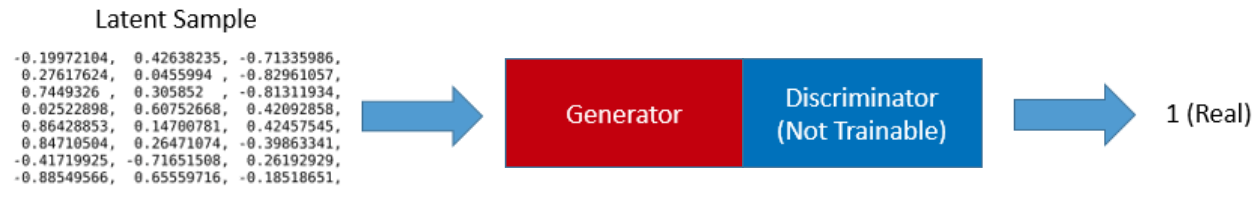

Si la imagen de dígito generada es tan realista, el discriminador en el GAN la clasifica como real, que es lo que queremos lograr.

Establecemos el discriminador dentro del GAN como no entrenable, por lo que simplemente evalúa la calidad de la imagen generada. La etiqueta siempre es 1 (real), de modo que si el generador no logra producir una imagen de dígito realista, su costo se vuelve alto y cuando se produce la retropropagación en el GAN, los pesos en la red del generador se actualizan.

In [ ]:
#Mantener los mismos pesos compartidos entre el generador y el discriminador.

gan = Sequential([generator, discriminator])
gan.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ generator (Sequential)          │ (None, 784)            │       114,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator (Sequential)      │ (None, 1)              │       100,609 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,673 (838.57 KB)

 Trainable params: 214,673 (838.57 KB)

 Non-trainable params: 0 (0.00 B)

Como puedes ver, el GAN utiliza internamente los mismos modelos de generador y discriminador. El GAN mantiene los mismos pesos compartidos con el generador y el discriminador. Por lo tanto, entrenar el GAN también entrena el generador. Sin embargo, no queremos que el discriminador se vea afectado mientras se entrena el GAN.

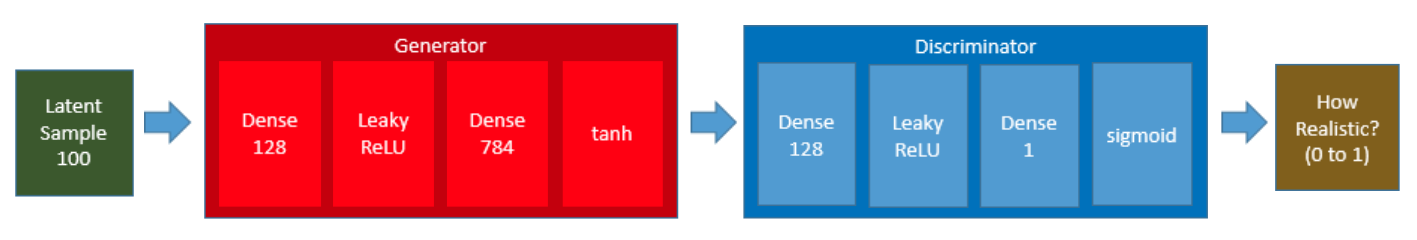

Entrenamos el discriminador y el GAN por turnos y repetimos el entrenamiento muchas veces hasta que ambos estén bien entrenados.   

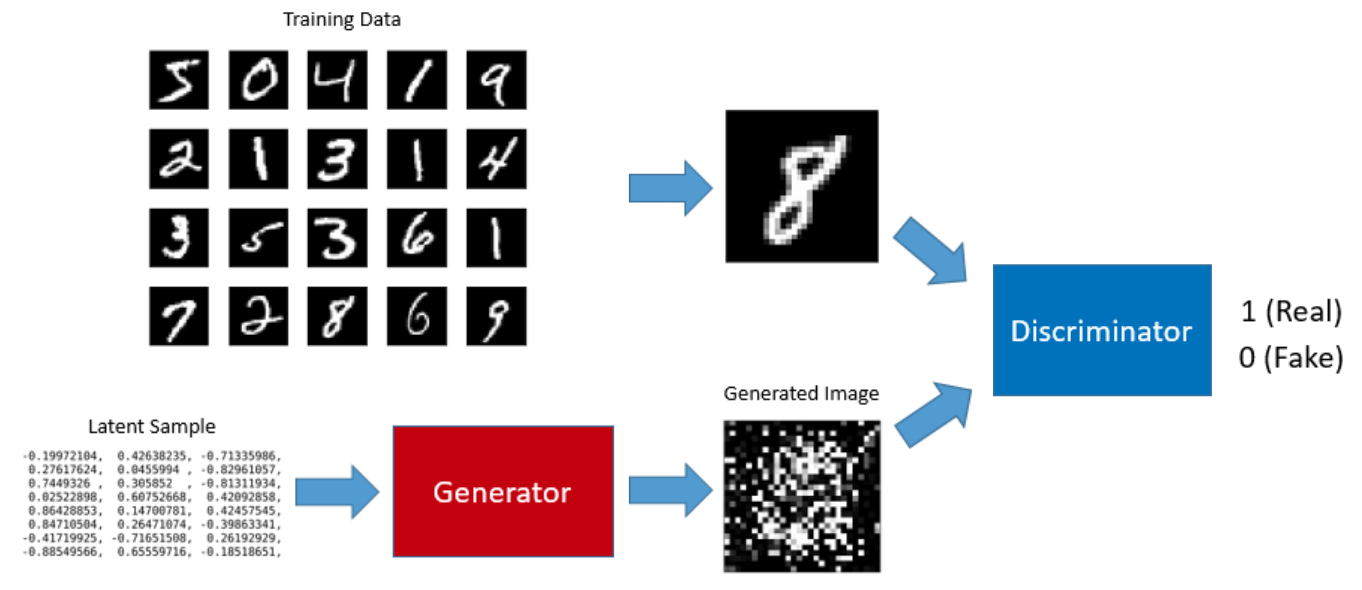

Durante el entrenamiento del GAN, la retropropagación debería actualizar los pesos del generador pero no los del discriminador.

Por lo tanto, necesitamos una forma de hacer que el discriminador sea entrenable y no entrenable.

In [ ]:
def make_trainable(model, trainable):
    for layer in model.layers:
        layer.trainable = trainable

In [ ]:
make_trainable(discriminator, False)
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 100,609 (393.00 KB)

In [ ]:
make_trainable(discriminator, True)
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

La siguiente función combina todo lo que hemos discutido hasta ahora para construir los modelos del generador, discriminador y GAN, y también los compila para el entrenamiento.

In [ ]:
def make_simple_GAN(sample_size, g_hidden_size, d_hidden_size, leaky_alpha, g_learning_rate, d_learning_rate):
    K.clear_session()

    generator = Sequential([Dense(g_hidden_size, input_shape=(sample_size,)), LeakyReLU(alpha=leaky_alpha), Dense(784), Activation('tanh')], name='generator')

    discriminator = Sequential([Dense(d_hidden_size, input_shape=(784,)), LeakyReLU(alpha=leaky_alpha), Dense(1), Activation('sigmoid')], name='discriminator')

    gan = Sequential([generator, discriminator])

    discriminator.compile(optimizer=Adam(learning_rate=d_learning_rate), loss='binary_crossentropy')
    gan.compile(optimizer=Adam(learning_rate=g_learning_rate), loss='binary_crossentropy')

    return gan, generator, discriminator

## Entrenamiento de GAN

### Preprocesamiento

Necesitamos aplanar los datos de las imágenes de dígitos, ya que la capa de entrada completamente conectada espera eso. Además, como el generador utiliza la activación **tanh** en la capa de salida, escalamos todas las imágenes de MNIST para que tengan valores entre -1 y 1.

In [ ]:
def preprocess(x):
    x = x.reshape(-1, 784) # 784=28*28
    x = np.float64(x)
    x = (x / 255 - 0.5) * 2
    x = np.clip(x, -1, 1)
    return x

In [ ]:
X_train_real = preprocess(X_train)
X_test_real  = preprocess(X_test)

In [ ]:
X_train_real.shape,X_train_real[0].shape,np.max(X_train_real[0]),np.min(X_train_real[0])

((60000, 784), (784,), np.float64(1.0), np.float64(-1.0))

### Desprocesamiento

También necesitamos una función para revertir el preprocesamiento de modo que podamos mostrar las imágenes generadas.

In [ ]:
def deprocess(x):
    x = (x / 2 + 1) * 255
    x = np.clip(x, 0, 255)
    x = np.uint8(x)
    x = x.reshape(28, 28)
    return x

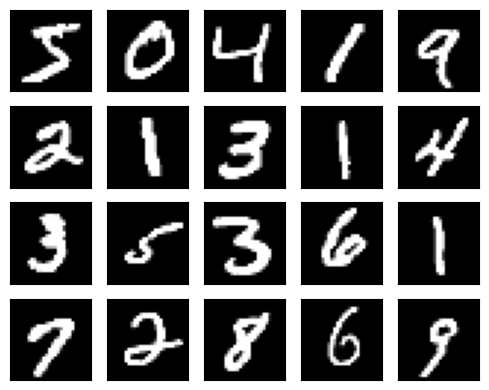

In [ ]:
plt.figure(figsize=(5, 4))
for i in range(20):
    img = deprocess(X_train_real[i])
    plt.subplot(4, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

### Etiquetas

Las etiquetas son 1 (real) o 0 (falsa) en forma 2D.

In [ ]:
def make_labels(size):
    return np.ones([size, 1]), np.zeros([size, 1])

Lo siguiente son 10 conjuntos de valores de etiquetas reales y falsas.

In [ ]:
y_real_10, y_fake_10 = make_labels(10)

y_real_10, y_fake_10

(array([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]]))

Más adelante, preparamos las etiquetas para el entrenamiento y la evaluación utilizando el tamaño del lote de entrenamiento y el tamaño de prueba.

### Suavizado de Etiquetas

Un último punto antes de comenzar el entrenamiento es el suavizado de etiquetas, que hace que el discriminador generalice mejor [[4]](#ref4).

Para las imágenes reales de dígitos, las etiquetas son todas 1. Sin embargo, cuando entrenamos el discriminador, usamos un valor ligeramente menor que 1 con las imágenes reales de dígitos. De lo contrario, el discriminador podría ajustarse demasiado a los datos de entrenamiento y rechazar cualquier cosa que sea ligeramente diferente de las imágenes de entrenamiento.

### Bucle de Entrenamiento

Repetimos lo siguiente para mejorar cada vez más tanto el discriminador como el generador:

* Preparar un lote de imágenes reales.
* Preparar un lote de imágenes falsas generadas por el generador utilizando muestras latentes.
* Hacer que el discriminador sea entrenable.
* Entrenar al discriminador para clasificar las imágenes reales y falsas.
* Hacer que el discriminador no sea entrenable.
* Entrenar al generador a través del GAN.

Cuando entrenamos al generador a través del GAN, las etiquetas esperadas son todas 1 (real). Inicialmente, el generador produce imágenes no muy realistas, por lo que el discriminador las clasifica como 0 (falsas), lo que provoca que la retropropagación ajuste los pesos dentro del generador. El discriminador no se ve afectado, ya que lo configuramos como no entrenable en este paso.

In [ ]:
# hyperparameters
sample_size     = 100     # latent sample size (i.e., 100 random numbers)
g_hidden_size   = 128
d_hidden_size   = 128
leaky_alpha     = 0.01
#leaky_alpha     = 0.2
g_learning_rate = 0.0001  # learning rate for the generator
d_learning_rate = 0.001   # learning rate for the discriminator
epochs          = 90
batch_size      = 64      # train batch size
eval_size       = 16      # evaluate size
smooth          = 0.1

# labels for the batch size and the test size
y_train_real, y_train_fake = make_labels(batch_size)
y_eval_real,  y_eval_fake  = make_labels(eval_size)

# create a GAN, a generator and a discriminator
gan, generator, discriminator = make_simple_GAN(sample_size, g_hidden_size, d_hidden_size, leaky_alpha, g_learning_rate, d_learning_rate)

losses = []
for e in range(epochs):
    for i in range(len(X_train_real)//batch_size):
        # real MNIST digit images
        X_batch_real = X_train_real[i*batch_size:(i+1)*batch_size]

        # latent samples and the generated digit images
        latent_samples = make_latent_samples(batch_size, sample_size)
        X_batch_fake = generator.predict_on_batch(latent_samples)

        # train the discriminator to detect real and fake images
        make_trainable(discriminator, True)
        discriminator.train_on_batch(X_batch_real, y_train_real * (1 - smooth))
        discriminator.train_on_batch(X_batch_fake, y_train_fake)

        # train the generator via GAN
        make_trainable(discriminator, False)
        gan.train_on_batch(latent_samples, y_train_real)

    # evaluate
    X_eval_real = X_test_real[np.random.choice(len(X_test_real), eval_size, replace=False)]

    latent_samples = make_latent_samples(eval_size, sample_size)
    X_eval_fake = generator.predict_on_batch(latent_samples)

    d_loss  = discriminator.test_on_batch(X_eval_real, y_eval_real)
    d_loss += discriminator.test_on_batch(X_eval_fake, y_eval_fake)
    g_loss  = gan.test_on_batch(latent_samples, y_eval_real) # we want the fake to be realistic!

    losses.append((d_loss, g_loss))

    print("Epoch: {:>3}/{} Discriminator Loss: {:>6.4f} Generator Loss: {:>6.4f}".format(e+1, epochs, d_loss, g_loss))

Epoch:   1/90 Discriminator Loss: 0.4186 Generator Loss: 3.6816
Epoch:   2/90 Discriminator Loss: 0.4309 Generator Loss: 3.6964
Epoch:   3/90 Discriminator Loss: 0.4345 Generator Loss: 3.7551
Epoch:   4/90 Discriminator Loss: 0.4433 Generator Loss: 3.7881
Epoch:   5/90 Discriminator Loss: 0.4517 Generator Loss: 3.7927
Epoch:   6/90 Discriminator Loss: 0.4585 Generator Loss: 3.7964
Epoch:   7/90 Discriminator Loss: 0.4643 Generator Loss: 3.7922
Epoch:   8/90 Discriminator Loss: 0.4700 Generator Loss: 3.7814
Epoch:   9/90 Discriminator Loss: 0.4778 Generator Loss: 3.7595
Epoch:  10/90 Discriminator Loss: 0.4871 Generator Loss: 3.7386
Epoch:  11/90 Discriminator Loss: 0.4970 Generator Loss: 3.7091
Epoch:  12/90 Discriminator Loss: 0.5056 Generator Loss: 3.6812
Epoch:  13/90 Discriminator Loss: 0.5127 Generator Loss: 3.6583
Epoch:  14/90 Discriminator Loss: 0.5194 Generator Loss: 3.6410
Epoch:  15/90 Discriminator Loss: 0.5250 Generator Loss: 3.6289
Epoch:  16/90 Discriminator Loss: 0.5299

### Estabilización de GAN

Resulta que entrenar un GAN es bastante difícil y se requieren muchos trucos y heurísticas [[4]](#ref4). Esto se debe a que el discriminador y el generador no cooperan y aprenden individualmente a predecir mejor.

Por ejemplo, el generador podría aprender a engañar al discriminador con basura. Idealmente, el discriminador debería aprender antes que el generador para que pueda clasificar las imágenes con precisión.

Por lo tanto, utilicé tasas de aprendizaje diferentes para el generador y el discriminador. Quería ralentizar el aprendizaje del generador para que el discriminador aprendiera a clasificar bien.

A medida que el generador aprende más y la pérdida disminuye, la pérdida del discriminador aumenta. Hay una especie de equilibrio alrededor de las 80-90 épocas.

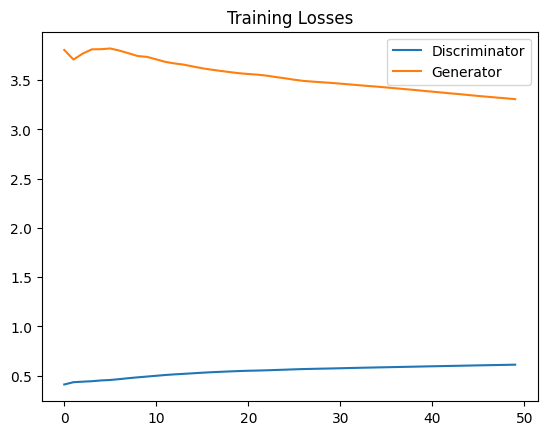

In [ ]:
losses = np.array(losses)

fig, ax = plt.subplots()
plt.plot(losses.T[0], label='Discriminator')
plt.plot(losses.T[1], label='Generator')
plt.title("Training Losses")
plt.legend()
plt.show()

### Seguimiento de Fallas

Según [[4]](#ref4),

- Una pérdida del discriminador igual a 0 significa que algo está mal.
- Cuando las cosas funcionan, la pérdida del discriminador tiene baja varianza y disminuye con el tiempo.
- Cuando las cosas no funcionan, la pérdida del discriminador tiene una gran varianza y picos.
- Si la pérdida del generador disminuye constantemente, está engañando al discriminador con basura.

### No equilibrar mediante estadísticas de pérdida

Según [[4]](#ref4),

- Es decir, no trates de encontrar un programa (número de G/número de D) para descolapsar el entrenamiento.

## Probando el Generador

Ahora generamos algunas imágenes de dígitos utilizando el generador entrenado.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


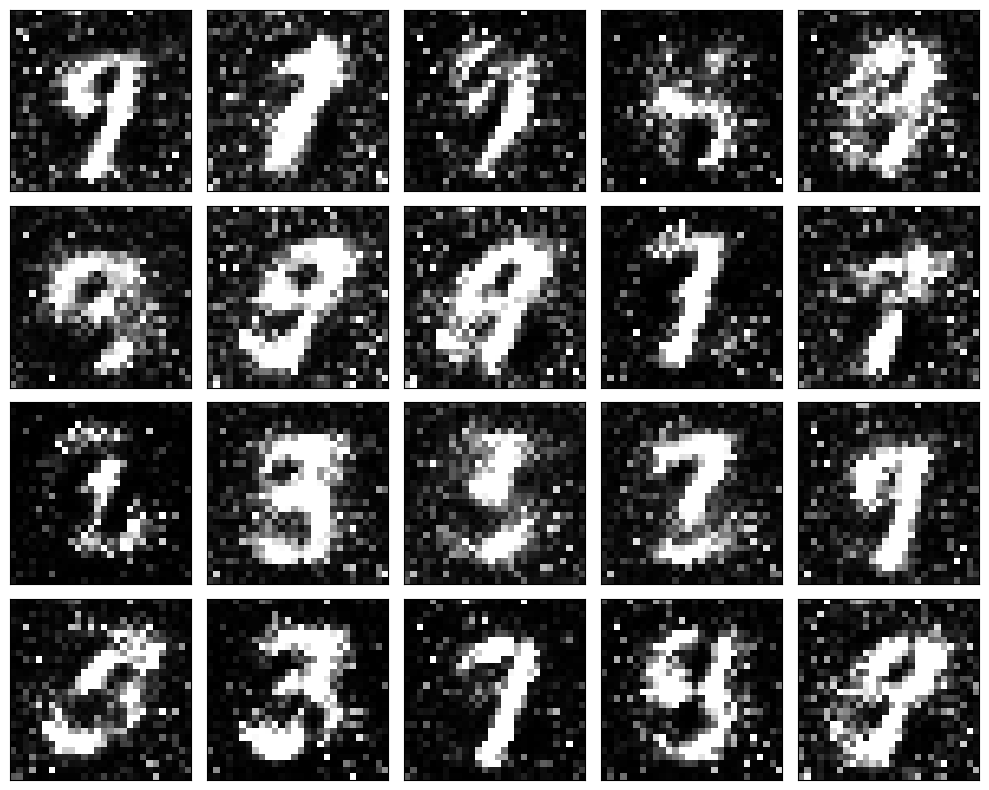

In [ ]:
latent_samples = make_latent_samples(20, sample_size)
generated_digits = generator.predict(latent_samples)

plt.figure(figsize=(10, 8))
for i in range(20):
    img = deprocess(generated_digits[i])
    plt.subplot(4, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

Los resultados no son sobresalientes ya que estamos utilizando redes simples. Una Red Generativa Adversarial Convolucional Profunda (conocida como DCGAN) produciría mejores resultados que esto.

## Referencias

<a id="ref1"></a>
### [1] Generative Adversarial Networks

Ian J. Goodfellow, Jean Pouget-Abadie, Mehdi Mirza, Bing Xu, David Warde-Farley, Sherjil Ozair, Aaron Courville, Yoshua Bengio
  
https://arxiv.org/abs/1406.2661

<a id="ref2"></a>
### [2] GAN MNIST Example in TensorFlow

Udacity

https://github.com/udacity/deep-learning/tree/master/gan_mnist

<a id="ref3"></a>
### [3] MNIST dataset

Yann LeCun

http://yann.lecun.com/exdb/mnist/

<a id="ref4"></a>
### [4] How to Train a GAN? Tips and tricks to make GANs work

Facebook AI Research: Soumith Chintala, Emily Denton, Martin Arjovsky, Michael Mathieu

https://github.com/soumith/ganhacks

https://www.youtube.com/watch?v=X1mUN6dD8uE
